# elevator-rmnd

Use the simulated dataset generated by `dataset.py` to train
regression models, in order to predict the remaining useful life (RUL)
of lifts.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
sns.set_theme(context="notebook", style="white")

## preprocessing
* Import the simulated dataset
* Convert lift ids to integers
* ~~Compute instantaneous time derivatives of each sensor metric~~ [called off for now]
* Compute RUL in h
* Split data into training/testing sets
* Scale data with a `Scaler`

In [31]:
df_full = pd.read_csv("predictive_maintenance_lifts.csv")
df_full.head(10)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done
0,2023-01-01 00:00:00,LIFT_001,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0
1,2023-01-01 12:00:00,LIFT_001,Otis Gen2,15012,0.490,1.883,0.386,10.544,33.781,0
2,2023-01-02 00:00:00,LIFT_001,Otis Gen2,15024,0.509,2.214,0.252,9.202,34.980,0
3,2023-01-02 12:00:00,LIFT_001,Otis Gen2,15036,0.539,2.688,0.668,10.468,35.398,0
4,2023-01-03 00:00:00,LIFT_001,Otis Gen2,15048,0.524,2.671,0.844,10.225,35.197,0
5,2023-01-03 12:00:00,LIFT_001,Otis Gen2,15060,0.541,2.667,0.981,10.564,36.912,0
6,2023-01-04 00:00:00,LIFT_001,Otis Gen2,15072,0.528,2.974,1.734,11.412,37.046,0
7,2023-01-04 12:00:00,LIFT_001,Otis Gen2,15084,0.580,2.908,1.058,11.337,36.593,0
8,2023-01-05 00:00:00,LIFT_001,Otis Gen2,15096,0.544,3.065,1.345,11.153,38.018,0
9,2023-01-05 12:00:00,LIFT_001,Otis Gen2,15108,0.598,3.386,1.919,11.118,37.117,0


Convert `lift_model` to integer labels

In [32]:
# Convert unique string lift IDs to integer indices
lift_models = df_full["lift_model"].unique()
df_full["lift_idx"] = df_full["lift_model"].apply(
    lambda x: np.where(lift_models == x)[0][0]
)
df_full.head(30)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,lift_idx
0,2023-01-01 00:00:00,LIFT_001,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,0
1,2023-01-01 12:00:00,LIFT_001,Otis Gen2,15012,0.490,1.883,0.386,10.544,33.781,0,0
2,2023-01-02 00:00:00,LIFT_001,Otis Gen2,15024,0.509,2.214,0.252,9.202,34.980,0,0
3,2023-01-02 12:00:00,LIFT_001,Otis Gen2,15036,0.539,2.688,0.668,10.468,35.398,0,0
4,2023-01-03 00:00:00,LIFT_001,Otis Gen2,15048,0.524,2.671,0.844,10.225,35.197,0,0
5,2023-01-03 12:00:00,LIFT_001,Otis Gen2,15060,0.541,2.667,0.981,10.564,36.912,0,0
6,2023-01-04 00:00:00,LIFT_001,Otis Gen2,15072,0.528,2.974,1.734,11.412,37.046,0,0
7,2023-01-04 12:00:00,LIFT_001,Otis Gen2,15084,0.580,2.908,1.058,11.337,36.593,0,0
8,2023-01-05 00:00:00,LIFT_001,Otis Gen2,15096,0.544,3.065,1.345,11.153,38.018,0,0
9,2023-01-05 12:00:00,LIFT_001,Otis Gen2,15108,0.598,3.386,1.919,11.118,37.117,0,0


Compute the **RUL** for each record in the dataset by
calculating the number of hours between the current log
and the next maintenance event (where `maintenance_done == 1`).

This computation should be _specific_ to the lift model only, i.e. filter by lift model first.

In [33]:
# Compute the RUL for each record in the dataset
def compute_rul(record: pd.Series, avail_maintenances: pd.DataFrame) -> float:
    """
    Compute the remaining useful life (RUL) in h for a given record.
    """
    time_now = record["timestamp"]
    # Get the next available maintenance (should be greater than the current time)
    next_available_maintenance = avail_maintenances[
        avail_maintenances["timestamp"] >= time_now
    ]["timestamp"].min()
    # If no further maintenance exists, then RUL is np.inf
    if pd.isna(next_available_maintenance):
        return np.inf
    # If there exists a further maintenance, compute the RUL in hours
    time_now = pd.to_datetime(time_now).to_pydatetime()
    next_available_maintenance = pd.to_datetime(
        next_available_maintenance
    ).to_pydatetime()
    return (next_available_maintenance - time_now).total_seconds() / 3600


maintenance_events = df_full[df_full["maintenance_done"] == 1]
for model in lift_models:
    # Get a list of all maintenance events for the current lift model
    available_maintenance_events = maintenance_events[
        maintenance_events["lift_model"] == model
    ]
    # Get all log events for the current lift model
    log_events = df_full[df_full["lift_model"] == model]
    # Then compute the RUL for each log event for each lift model
    for idx, record in log_events.iterrows():
        rul = compute_rul(record, available_maintenance_events)
        df_full.at[idx, "RUL_hrs"] = rul

# Dummy checks
assert not any(df_full["RUL_hrs"].isna()), "RUL_hrs should not have any null values"
assert not any(df_full["RUL_hrs"] < 0), "RUL_hrs should not have any negative values"
df_full.tail(10)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,lift_idx,RUL_hrs
59990,2050-05-14 00:00:00,LIFT_003,KONE MonoSpace,248380,0.782,3.901,7.974,14.165,58.142,0,2,inf
59991,2050-05-14 12:00:00,LIFT_003,KONE MonoSpace,248392,0.769,3.839,8.056,14.307,62.702,0,2,inf
59992,2050-05-15 00:00:00,LIFT_003,KONE MonoSpace,248404,0.786,3.892,8.535,14.803,61.860,0,2,inf
59993,2050-05-15 12:00:00,LIFT_003,KONE MonoSpace,248416,0.805,4.105,8.673,14.719,61.350,0,2,inf
59994,2050-05-16 00:00:00,LIFT_003,KONE MonoSpace,248428,0.776,3.815,8.701,14.746,63.592,0,2,inf
59995,2050-05-16 12:00:00,LIFT_003,KONE MonoSpace,248440,0.775,4.018,8.839,14.660,63.757,0,2,inf
59996,2050-05-17 00:00:00,LIFT_003,KONE MonoSpace,248452,0.797,4.176,9.229,15.118,62.345,0,2,inf
59997,2050-05-17 12:00:00,LIFT_003,KONE MonoSpace,248464,0.826,4.023,9.271,15.128,65.509,0,2,inf
59998,2050-05-18 00:00:00,LIFT_003,KONE MonoSpace,248476,0.816,4.143,9.397,14.338,65.689,0,2,inf
59999,2050-05-18 12:00:00,LIFT_003,KONE MonoSpace,248488,0.807,4.203,9.540,14.566,66.308,0,2,inf


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Since there exist rows that have `np.inf` as their predicted RUL, extract those rows for experimentation later on.
Retain the remaining roles (with valid RULs) for training and testing.

In [35]:
df_experimental = df_full[
    df_full["RUL_hrs"] == np.inf
]  # Filter out records with no further maintenance
df_useful = df_full[
    df_full["RUL_hrs"] != np.inf
]  # Retain the remaining records for training/testing

# Check to see the experimental/useful split was done correctly
assert all(
    df_experimental["RUL_hrs"] == np.inf
), "All records in experimental set should have RUL_hrs as np.inf"
assert all(
    df_useful["RUL_hrs"] != np.inf
), "All records in useful set should have valid RUL_hrs"

df_useful.head(40)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,lift_idx,RUL_hrs
0,2023-01-01 00:00:00,LIFT_001,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,0,504.0
1,2023-01-01 12:00:00,LIFT_001,Otis Gen2,15012,0.490,1.883,0.386,10.544,33.781,0,0,492.0
2,2023-01-02 00:00:00,LIFT_001,Otis Gen2,15024,0.509,2.214,0.252,9.202,34.980,0,0,480.0
3,2023-01-02 12:00:00,LIFT_001,Otis Gen2,15036,0.539,2.688,0.668,10.468,35.398,0,0,468.0
4,2023-01-03 00:00:00,LIFT_001,Otis Gen2,15048,0.524,2.671,0.844,10.225,35.197,0,0,456.0
5,2023-01-03 12:00:00,LIFT_001,Otis Gen2,15060,0.541,2.667,0.981,10.564,36.912,0,0,444.0
6,2023-01-04 00:00:00,LIFT_001,Otis Gen2,15072,0.528,2.974,1.734,11.412,37.046,0,0,432.0
7,2023-01-04 12:00:00,LIFT_001,Otis Gen2,15084,0.580,2.908,1.058,11.337,36.593,0,0,420.0
8,2023-01-05 00:00:00,LIFT_001,Otis Gen2,15096,0.544,3.065,1.345,11.153,38.018,0,0,408.0
9,2023-01-05 12:00:00,LIFT_001,Otis Gen2,15108,0.598,3.386,1.919,11.118,37.117,0,0,396.0


Then perform a 80/20 `train_test_split` on the remaining useful data.

In [36]:
X = df_useful.drop(
    columns=["timestamp", "lift_id", "lift_model", "maintenance_done", "RUL_hrs"]
)
y = df_useful["RUL_hrs"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

In [37]:
# Dummy checks
assert len(X_train) == len(
    y_train
), "X_train and y_train should have the same number of records"
assert len(X_test) == len(
    y_test
), "X_test and y_test should have the same number of records"
assert y_train.isna().sum() == 0, "y_train should not have any null values"
assert y_test.isna().sum() == 0, "y_test should not have any null values"

Use `StandardScaler` to transform the data (for classical ML techniques).

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## classical ML techniques
We experiment with a few classical regression techniques and evaluate them on a set of metrics.
Metrics of interest include:
* mean absolute error (`mae`): the mean deviation (in h) of predicted RUL from true RUL
* r2 score (`r2`): how well the true RUL and predicted RUL match up

### classical 1: `SVR`
Use [`SVR`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) to regress $Y$ (RUL) against $X$ (all metadata and sensor readings).
Support vector regression was chosen because it has the ability to handle non-linear relationships.

In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel="linear", epsilon=0.1)
svr.fit(X_train, y_train)
y_hat_svr = svr.predict(X_test)
mse_svr = mean_squared_error(y_test, y_hat_svr)
print(f"MSE (SVR): {mse_svr:.4f}")
mae_svr = mean_absolute_error(y_test, y_hat_svr)
print(f"MAE (SVR): {mae_svr:.4f}")
r2_svr = r2_score(y_test, y_hat_svr)
print(f"R2 (SVR): {r2_svr:.4f}")

MSE (SVR): 19961.8686
MAE (SVR): 93.2395
Accuracy (SVR): 0.0046


### classical 2: `ElasticNet`
[`ElasticNet`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)
is a form of linear regression, with combined L1 and L2 regularisers.

In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=67)
elastic.fit(X_train, y_train)
y_hat_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_hat_elastic)
print(f"MSE (ElasticNet): {mse_elastic:.4f}")
mae_elastic = mean_absolute_error(y_test, y_hat_elastic)
print(f"MAE (ElasticNet): {mae_elastic:.4f}")
r2_elastic = r2_score(y_test, y_hat_elastic)
print(f"R2 (ElasticNet): {r2_elastic:.4f}")

MSE (ElasticNet): 19234.9150
MAE (ElasticNet): 95.7032
Accuracy (ElasticNet): 0.0038


### classical 3: `XGBoost`
[`XGBoost`](https://xgboost.readthedocs.io/en/stable/index.html) is one of the most
robust classical ML techniques.

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
)
xgb_model.fit(X_train, y_train)
y_hat_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_hat_xgb)
print(f"MSE (XGBoost): {mse_xgb:.4f}")
mae_xgb = mean_absolute_error(y_test, y_hat_xgb) 
print(f"MAE (XGBoost): {mae_xgb:.4f}")
r2_xgb = r2_score(y_test, y_hat_xgb)
print(f"R2 (XGBoost): {r2_xgb:.4f}")

MSE (XGBoost): 5265.5564
MAE (XGBoost): 46.4701
Accuracy (XGBoost): 0.0114


### classical 4: `RandomForestRegressor`
Another regressor, using [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, max_depth=6)
rf.fit(X_train, y_train)
y_hat_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_hat_rf)
print(f"MSE (Random Forest): {mse_rf:.4f}")
mae_rf = mean_absolute_error(y_test, y_hat_rf)
print(f"MAE (Random Forest): {mae_rf:.4f}")
r2_rf = r2_score(y_test, y_hat_rf)
print(f"R2 (Random Forest): {r2_rf:.4f}")

MSE (Random Forest): 14131.5331
MAE (Random Forest): 73.6214
R2 (Random Forest): 0.7795


Compile all the plots into one, for easier viewing of accuracy.

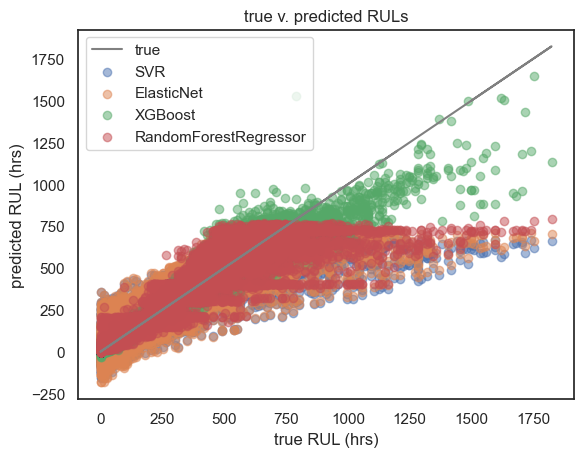

In [ ]:
plt.title("true v. predicted RULs")
plt.xlabel("true RUL (hrs)")
plt.ylabel("predicted RUL (hrs)")
plt.plot(y_test, y_test, label="true", color="gray")
plt.scatter(y_test, y_hat_svr, label="SVR", alpha=.5)
plt.scatter(y_test, y_hat_elastic, label="ElasticNet", alpha=.5)
plt.scatter(y_test, y_hat_xgb, label="XGBoost", alpha=.5)
plt.scatter(y_test, y_hat_rf, label="RandomForestRegressor", alpha=.5)
plt.legend()

Text(0, 0.5, 'mae (days)')

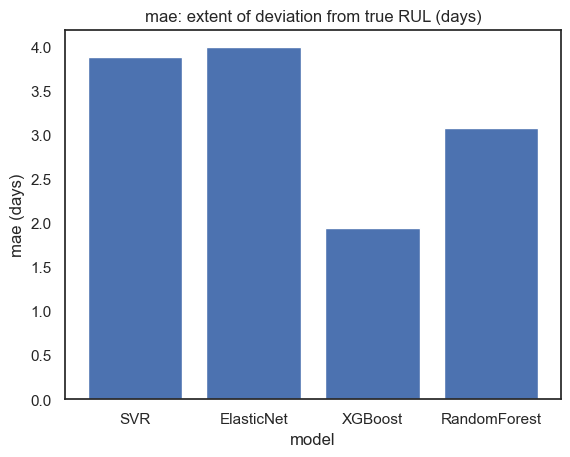

In [80]:
models = ["SVR", "ElasticNet", "XGBoost", "RandomForest"]
maes = [mae_svr, mae_elastic, mae_xgb, mae_rf]
maes = [round(mae/24, 2) for mae in maes]
plt.bar(models, maes)
plt.title("mae: extent of deviation from true RUL (days)")
plt.xlabel("model")
plt.ylabel("mae (days)")